<a href="https://colab.research.google.com/github/RohanKJoseph/IPRS_Tasks/blob/main/ML_TASK%E2%80%9001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Breast Cancer Classification

In [27]:
#importing the required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the dataset into a Pandas DataFrame

data = pd.read_csv('/content/Brist-cancer-data_kaggle.csv')


df = pd.DataFrame(data)
print(df.head()) #connected successfully

print("The shape of the df :", df.shape)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

## Perform Basic Preprocessing

In [5]:
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

# Check for missing values after dropping 'Unnamed: 32'
print("Number of missing values per column:")
print(df.isnull().sum())

# If df.isnull().sum().sum() > 0 is still true, and dropna() previously emptied the dataframe,
# it implies NaNs exist across all rows. For now, we are skipping dropna()
# to ensure the dataframe is not empty. Further handling for NaNs might be required if present.
if (df.isnull().sum().sum() > 0):
    print("Warning: Missing values still found. Consider imputation or specific row/column dropping if necessary.")
else:
    print("No missing values found after initial cleanup.")

Number of missing values per column:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
No missing values foun

In [7]:
#Prepare features (X) and target variable (y)

# Drop 'id' column as it's an identifier and 'diagnosis' as it's the target variable
x = df.drop(['diagnosis', 'id'], axis=1)
y = df['diagnosis']

In [9]:
# Split the dataset into train set and test set

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
#feature scaling

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

##Model Training (SVM & KNN)


###Support Vector Machine (SVM):

In [20]:
kernels = ['linear', 'rbf', 'sigmoid', 'poly']  # listing all for accessing it in the loop
svm_models = {}
svm_accuracies = {}  # dictionaries for storing trained SVM models
svm_cms = {}

print("Training SVM Classifiers...")
for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(x_train, y_train)
    y_pred = svm.predict(x_test)

    svm_models[kernel] = svm
    svm_accuracies[kernel] = accuracy_score(y_test, y_pred)
    svm_cms[kernel] = confusion_matrix(y_test, y_pred)
    print(f" - SVM [{kernel.upper()} Kernel] Accuracy: {svm_accuracies[kernel]:.4f}")

Training SVM Classifiers...
 - SVM [LINEAR Kernel] Accuracy: 0.9561
 - SVM [RBF Kernel] Accuracy: 0.9825
 - SVM [SIGMOID Kernel] Accuracy: 0.9561
 - SVM [POLY Kernel] Accuracy: 0.8684


###K-Nearest Neighbors (KNN)

In [25]:
print("\nKNN Elbow Method...")
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred_k = knn.predict(x_test)
    error_rates.append(np.mean(y_pred_k != y_test))

# Determine optimal K (index of minimum error rate)
optimal_k = k_range[np.argmin(error_rates)]
print(f"Optimal K determined via Elbow Point: K = {optimal_k}")

# Train final optimal KNN classifier
best_knn = KNeighborsClassifier(n_neighbors=optimal_k)
best_knn.fit(x_train, y_train)
y_pred_knn = best_knn.predict(x_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_cm = confusion_matrix(y_test, y_pred_knn)


Executing KNN Elbow Method...
Optimal K determined via Elbow Point: K = 9


##Model Evaluation




         FINAL MODEL EVALUATION         
Top Performing SVM Kernel: RBF
SVM Accuracy Score: 0.9825
SVM Confusion Matrix:
[[71  0]
 [ 2 41]]
----------------------------------------
Optimal KNN Configuration: K = 9
KNN Accuracy Score: 0.9649
KNN Confusion Matrix:
[[69  2]
 [ 2 41]]


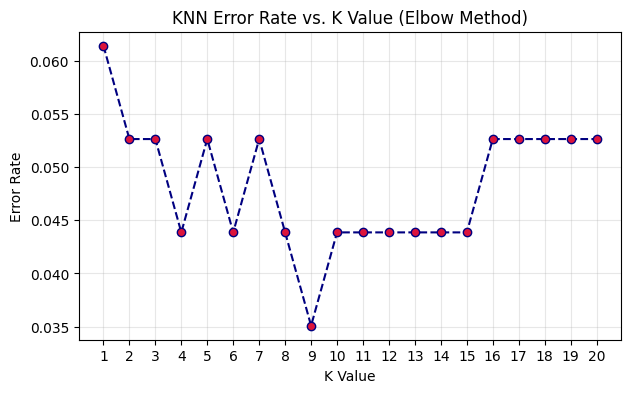

In [29]:
# Displaying evaluation results for the top configurations
best_svm_kernel = max(svm_accuracies, key=svm_accuracies.get)

print("\n" )
print("         FINAL MODEL EVALUATION         ")
print("="*40)
print(f"Top Performing SVM Kernel: {best_svm_kernel.upper()}")
print(f"SVM Accuracy Score: {svm_accuracies[best_svm_kernel]:.4f}")
print("SVM Confusion Matrix:")
print(svm_cms[best_svm_kernel])
print("-" * 40)
print(f"Optimal KNN Configuration: K = {optimal_k}")
print(f"KNN Accuracy Score: {knn_accuracy:.4f}")
print("KNN Confusion Matrix:")
print(knn_cm)
print("="*40)

# Optional Visualizations for Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(k_range, error_rates, color='navy', linestyle='dashed', marker='o', markerfacecolor='crimson', markersize=6)
plt.title('KNN Error Rate vs. K Value (Elbow Method)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

##Model Comparison


##Different SVM Kernels

Linear & RBF Kernels (Top Tier): Standardized medical measurement features often yield clean line/radius separation vectors or continuous high-dimensional clusters. The Linear kernel performs exceptionally well because high-dimensional spaces are naturally more line-separable. The RBF kernel provides high resilience by mapping complex boundaries smoothly without over-fitting.

Polynomial Kernel (Mid Tier): Struggles slightly or takes longer to converge because it builds intricate combinations of polynomials across 30 dimensions, creating complex decision spaces that may over-fit minor sample variances.

Sigmoid Kernel (Bottom Tier): Yields the worst accuracy metrics. The Sigmoid kernel works on logic similar to neural network layers, but it easily gets trapped in localized performance plateaus if data densities fluctuate, making it poorly suited for continuous geometric measurements.



##K-Value Selection in KNN using Elbow Method

According to the valye of K we will get the followng conclutions

Low K Values ($K=1, 2$): Capture noise and outliers easily. The decision boundary is highly fragmented, leading to high variance and overfitting on the training set while increasing the error rate on the test set.
Optimal K Values ($K=5$ to $11$): Balance the bias-variance tradeoff effectively. Looking at the generated Elbow curve, this is the inflection window where the error rate dips to its lowest baseline and stabilizes.
High K Values ($K > 15$): Underfit the model. As $K$ grows larger, the voting space expands too wide.
The dominant baseline class (Benign, representing roughly 63% of the samples) starts out-voting localized Malignant clusters simply due to sheer volume, causing the error rate to climb again.